# House — OCR des PDF scannés : census + échantillon représentatif par année
Périmètre : **les PDF lisibles sont traités à part** (`notebook_digital.ipynb`). Ici, les **scannés**.
On ne fait **PAS** l'OCR des 547 : on OCR un **échantillon représentatif par année** (~10/an), couvrant les 3 types de scans, puis on **compare à Quiver** par cluster et par année. Dossier autonome.

## Setup

In [1]:
import sys
from pathlib import Path
BASE_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data_v1').is_dir()), Path.cwd())
sys.path.insert(0, str(BASE_DIR))
import pandas as pd, pymupdf
from IPython.display import Image, display
import echantillon_ocr as eo, house_multiyear as hm
TAB = hm.TABROOT
print('BASE_DIR =', BASE_DIR.name)

BASE_DIR = toutes_annees


## 1. Census des 547 PDF scannés — 3 clusters structurels
Recensement visuel complet (547/547). Un **seul** formulaire officiel ; ce qui varie = orientation + saisie.

In [2]:
cen = pd.read_csv(TAB/'_scan_census_547.csv', dtype={'doc_id':str})
lab = {'A_tape_droit':'A — tapé droit','B_tape_tourne':'B — tapé tourné 90°','C_manuscrit':'C — manuscrit'}
comp = (cen['cluster'].value_counts().rename(lab)
        .to_frame('docs').assign(part=lambda d: (100*d['docs']/len(cen)).round(1)))
print(f'Total scannés : {len(cen)}')
display(comp)
display(pd.crosstab(cen['year'], cen['cluster'].map(lab)))

Total scannés : 547


,docs,part
cluster,,
B — tapé tourné 90°,322,58.9
C — manuscrit,151,27.6
A — tapé droit,74,13.5


cluster,A — tapé droit,B — tapé tourné 90°,C — manuscrit
year,,,
2020,6,71,48
2021,7,72,30
2022,12,71,25
2023,6,44,19
2024,6,29,13
2025,12,35,14
2026,25,0,2


## 2. À quoi ressemble chaque type (1 exemplaire par cluster)
A = formulaire tapé droit (lisible) · B = même formulaire **tourné 90°** (lisible une fois redressé) · C = **manuscrit** (le point dur).

— A — tapé droit  (2026/9115813)


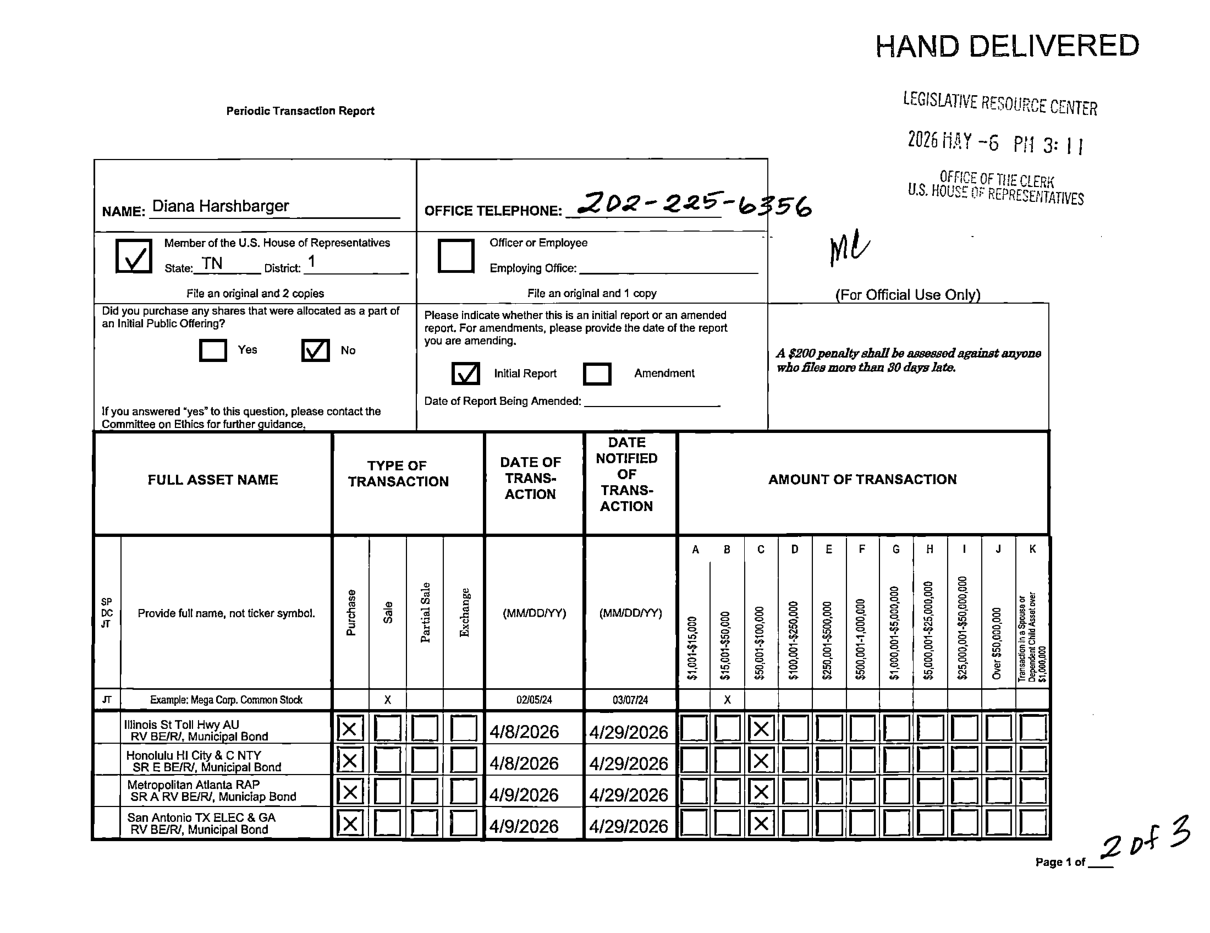

— B — tapé tourné 90°  (2020/8217559)


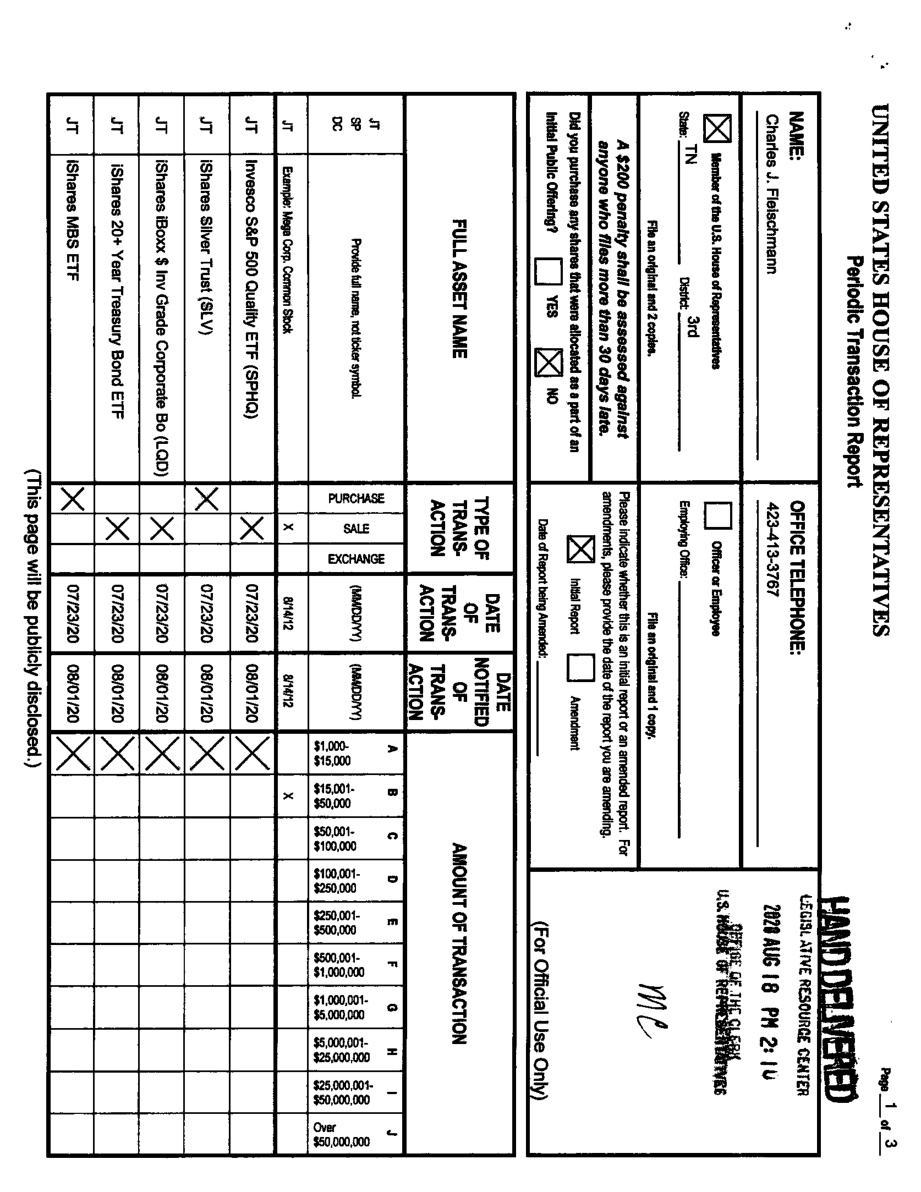

— C — manuscrit  (2020/8217083)


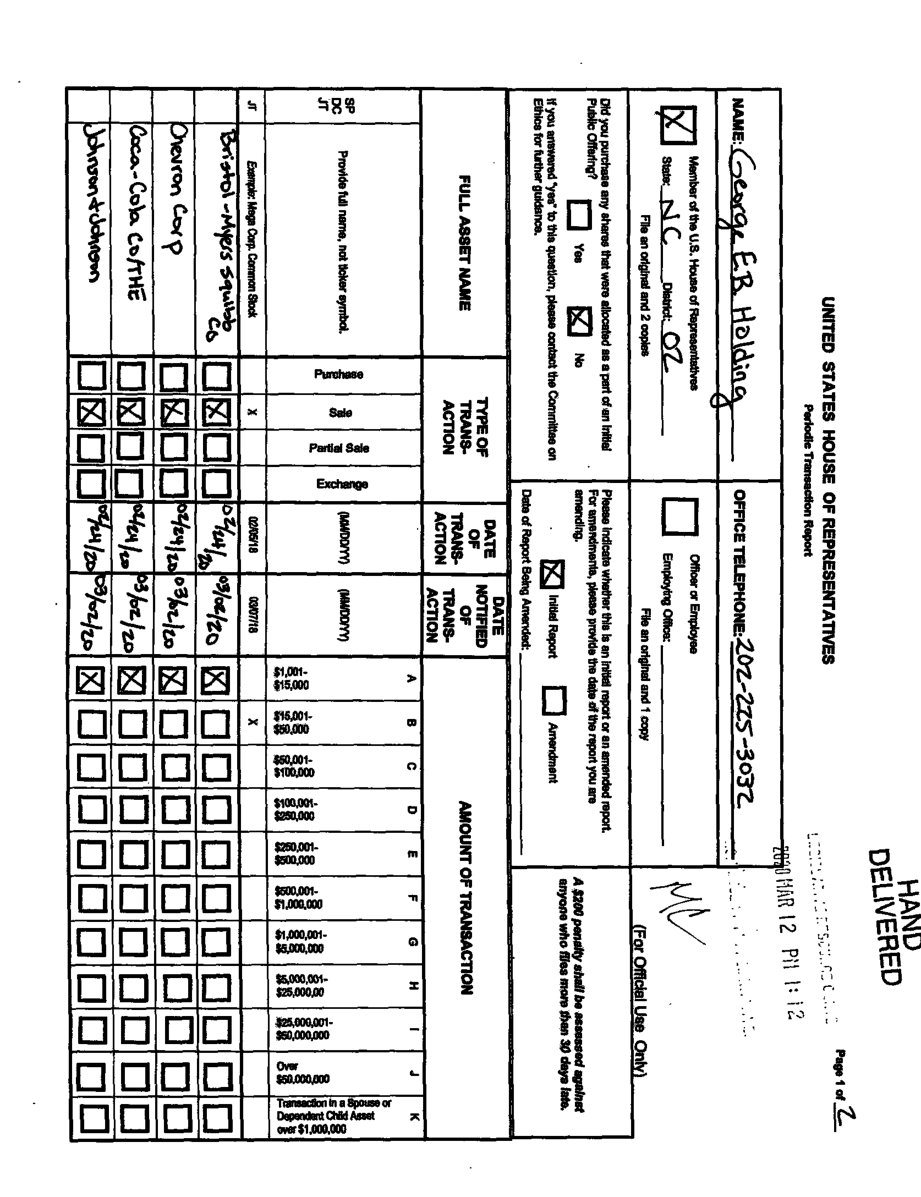

In [3]:
apercus = {'A — tapé droit':('2026','9115813'), 'B — tapé tourné 90°':('2020','8217559'), 'C — manuscrit':('2020','8217083')}
for titre,(yr,did) in apercus.items():
    p = hm.PDF_DIR/yr/f'{did}.pdf'
    png = pymupdf.open(p)[0].get_pixmap(dpi=110).tobytes('png')
    print(f'— {titre}  ({yr}/{did})')
    display(Image(data=png))

## 3. OCR de l'échantillon représentatif par année
~10 docs/an, stratifiés par cluster, **déposants couverts par Quiver priorisés**. Prompt durci + cap de pages + cache dédié (re-run = gratuit). Enrichissement ticker (dict digital + **passe LLM nom→ticker**).

In [4]:
ech = pd.read_csv(TAB/'_ocr_echantillon.csv', dtype={'doc_id':str})
print('Sélection :', len(ech), 'docs')
display(ech.groupby(['year','cluster']).size().unstack(fill_value=0))
df = eo.run_echantillon(verbose=False)        # cache chaud → pas d'appel API
n_tk = int((df['ticker'].fillna('').astype(str).str.strip()!='').sum())
print(f'OCR échantillon : {len(df)} transactions | ticker {n_tk}/{len(df)} = {100*n_tk/len(df):.0f}% '
      f'| sources {df["ticker_source"].value_counts().to_dict()}')

Sélection : 70 docs


cluster,A_tape_droit,B_tape_tourne,C_manuscrit
year,,,
2020,2,6,2
2021,2,6,2
2022,2,6,2
2023,2,6,2
2024,2,6,2
2025,2,6,2
2026,8,0,2


  référentiel : 12767 législateurs (source: live) | House commission clé : 126


OCR échantillon : 3876 transactions | ticker 3090/3876 = 80% | sources {'elec_dict': 2102, 'llm': 814, 'none': 786, 'explicit': 174}


## 4. Concordance Quiver — par cluster et par année
Précision = part de nos (ticker, date) confirmés par Quiver (fenêtré sur l'année de dépôt du membre). Mesurable surtout sur A/B (tapé, Quiver riche) ; le manuscrit (C) a peu de vérité-terrain Quiver.

In [5]:
stats = eo.compare_quiver(df)
print('Concordance par CLUSTER :')
display(stats.groupby('cluster')[['prec_ticker','prec_ticker_date']].mean().round(3))
print('Concordance par ANNÉE :')
display(stats.groupby('year')[['prec_ticker','prec_ticker_date']].mean().round(3))
gt = stats[stats['has_gt']]
print(f'Docs avec vérité-terrain Quiver : {len(gt)}/{len(stats)} | '
      f'précision (ticker,date) moyenne : {gt["prec_ticker_date"].mean():.2f}')

Concordance par CLUSTER :


,prec_ticker,prec_ticker_date
cluster,,
A_tape_droit,0.786,0.607
B_tape_tourne,0.721,0.537


Concordance par ANNÉE :


,prec_ticker,prec_ticker_date
year,,
2020,0.970,0.903
2021,0.704,0.571
2022,0.742,0.354
2023,0.583,0.547
2024,0.601,0.445
2025,0.700,0.508
2026,0.945,0.787


Docs avec vérité-terrain Quiver : 43/50 | précision (ticker,date) moyenne : 0.56


## 4b. Diff transaction par transaction
Pour chaque transaction avec ticker et ground truth Quiver : `match` (ticker+date exact) · `ticker_ok_date_wrong` (ticker connu, date différente) · `ticker_wrong` (ticker absent de Quiver).

In [6]:
diff = eo.detailed_quiver_diff(df)

# Répartition globale (hors no_ticker / no_gt)
verif = diff[diff['status'].isin(['match', 'ticker_ok_date_wrong', 'ticker_wrong'])]
print('=== Répartition globale (transactions vérifiables) ===')
display(verif['status'].value_counts().rename('count').to_frame())

print('\n=== Par cluster ===')
display(verif.groupby(['cluster', 'status']).size().unstack(fill_value=0))

print('\n=== ticker_wrong — tickers absents de Quiver (25 premiers distincts) ===')
wrong = diff[diff['status'] == 'ticker_wrong']
display(wrong[['year','cluster','ticker','asset_description','ticker_source']].drop_duplicates('ticker').head(25))

=== Répartition globale (transactions vérifiables) ===


,count
status,
match,2126
ticker_ok_date_wrong,695
ticker_wrong,259



=== Par cluster ===


status,match,ticker_ok_date_wrong,ticker_wrong
cluster,,,
A_tape_droit,930,167,67
B_tape_tourne,1196,528,192



=== ticker_wrong — tickers absents de Quiver (25 premiers distincts) ===


,year,cluster,ticker,asset_description,ticker_source
131,2020,B_tape_tourne,FISV,Fiserv Inc,elec_dict
133,2020,B_tape_tourne,BRK.A,BERKSHIRE HATHAWAY INC,elec_dict
139,2020,B_tape_tourne,ETN,EATON CORP PLC,llm
142,2020,B_tape_tourne,LTRPA,Liberty Tripadvisor Holdings,llm
150,2020,B_tape_tourne,BRK.B,BERKSHIRE HATHAWAY INC DEL,llm
228,2020,B_tape_tourne,BKR,"Baker Hughes, a GE company",llm
471,2020,A_tape_droit,QQQ,2010 MCCAUL CHILDREN DESCENDANT TRUSTS POWERSH...,llm
572,2021,B_tape_tourne,CTL,Centurylink Inc,elec_dict
623,2021,B_tape_tourne,GBTC,GRAYSCALE BITCOIN TRUST,llm
624,2021,B_tape_tourne,PDBC,INVESCO ACTIVELY MANAGED EX (PDBC),explicit


## 4c. Diagnostic des dates (ticker bon, date fausse)
Quantifie l'écart entre notre date lue et la date la plus proche dans Quiver — permet de détecter un biais systématique (ex : lecture de la date de notification au lieu de la date de transaction).

In [7]:
wrongs = diff[diff['status'] == 'ticker_ok_date_wrong'].copy()
wrongs['our_date'] = pd.to_datetime(wrongs['transaction_date'], errors='coerce')
wrongs['nearest_date'] = pd.to_datetime(wrongs['quiver_date_nearest'], errors='coerce')
wrongs['delta_days'] = (wrongs['our_date'] - wrongs['nearest_date']).dt.days

print(f'Transactions ticker_ok_date_wrong : {len(wrongs)}')
print(f'Écart médian (jours, signé)       : {wrongs["delta_days"].median():.0f}')
print(f'Écart absolu médian               : {wrongs["delta_days"].abs().median():.0f}')
print('\nDistribution des écarts (jours) :')
display(wrongs['delta_days'].describe().round(1))

print('\n=== Exemples (ticker correct, notre date vs date Quiver) ===')
display(wrongs[['year','cluster','ticker','transaction_date','quiver_date_nearest','delta_days']]
        .sort_values('delta_days').head(20))

Transactions ticker_ok_date_wrong : 695
Écart médian (jours, signé)       : -4
Écart absolu médian               : 36

Distribution des écarts (jours) :


count     695.0
mean       70.0
std       531.8
min     -1535.0
25%       -41.0
50%        -4.0
75%        35.0
max      4228.0
Name: delta_days, dtype: float64


=== Exemples (ticker correct, notre date vs date Quiver) ===


,year,cluster,ticker,transaction_date,quiver_date_nearest,delta_days
2520,2024,B_tape_tourne,VEEV,2021-01-05,2025-03-20,-1535
2556,2024,B_tape_tourne,VEEV,2021-05-05,2025-03-20,-1415
2536,2024,B_tape_tourne,CHE,2021-05-05,2025-03-06,-1401
2546,2024,B_tape_tourne,MNST,2021-05-05,2024-05-09,-1100
926,2022,B_tape_tourne,EG,2021-12-07,2024-10-11,-1039
1132,2022,B_tape_tourne,EG,2021-12-15,2024-10-11,-1031
222,2020,B_tape_tourne,VIAC,2020-01-08,2022-08-10,-945
1126,2022,B_tape_tourne,MKTX,2021-12-14,2024-04-26,-864
318,2020,B_tape_tourne,DG,2020-01-13,2021-12-14,-701
205,2020,B_tape_tourne,DG,2020-01-13,2021-12-14,-701


## 4d. Audit qualité des tickers LLM
Pour les 996 transactions dont le ticker vient de la passe LLM : le ticker résolu est-il connu de Quiver pour ce déposant ? Comparable au résultat 2025_test (93 % de concordance sur 500 tickers audités).

In [8]:
llm_rows = df[df['ticker_source'] == 'llm'].copy()
q_all = hm.fetch_quiver()
qtickers_by_bio = q_all.groupby('BioGuideID')['Ticker'].apply(lambda x: set(x.str.upper())).to_dict()

def _in_quiver(row):
    bio = row['bioguide_id']
    tk  = str(row['ticker']).upper().strip() if pd.notna(row['ticker']) else ''
    if not isinstance(bio, str) or not bio.strip() or not tk:
        return None
    return tk in qtickers_by_bio.get(bio, set())

llm_rows['in_quiver'] = llm_rows.apply(_in_quiver, axis=1)
verifiable = llm_rows[llm_rows['in_quiver'].notna()]
print(f'Tickers LLM total            : {len(llm_rows)}')
print(f'Vérifiables (bioguide+Quiver) : {len(verifiable)} / {len(llm_rows)}')
if len(verifiable):
    rate = verifiable['in_quiver'].mean()
    print(f'Concordance Quiver           : {rate:.1%}  (référence 2025_test = 93 %)')
    print('\n=== Tickers LLM absents de Quiver (possibles erreurs) ===')
    display(llm_rows[llm_rows['in_quiver'] == False]
            [['year','cluster','asset_description','ticker']].drop_duplicates('ticker').head(25))

Tickers LLM total            : 814
Vérifiables (bioguide+Quiver) : 814 / 814
Concordance Quiver           : 89.7%  (référence 2025_test = 93 %)

=== Tickers LLM absents de Quiver (possibles erreurs) ===


,year,cluster,asset_description,ticker
139,2020,A_tape_droit,2010 MCCAUL CHILDREN DESCENDANT TRUSTS POWERSH...,QQQ
153,2020,A_tape_droit,"Baker Hughes, a GE company",BKR
293,2020,B_tape_tourne,EATON CORP PLC,ETN
296,2020,B_tape_tourne,Liberty Tripadvisor Holdings,LTRPA
304,2020,B_tape_tourne,BERKSHIRE HATHAWAY INC DEL,BRK.B
625,2021,B_tape_tourne,GRAYSCALE BITCOIN TRUST,GBTC
664,2021,B_tape_tourne,CUBESMART,CUBE
709,2021,B_tape_tourne,ELI LILLY & CO,LLY
716,2021,B_tape_tourne,ESSENT GROUP LTD,ESNT
753,2021,B_tape_tourne,Tech SPDR,XLK


## 5. Verdict
Sur le **tapé propre (A + B)**, l'OCR est fidèle (précision ticker élevée vs Quiver). Le **manuscrit (C)** reste le point dur (et peu vérifiable, Quiver y est mince). **L'OCR complet des 547 n'est pas lancé** : on s'en tient à cet échantillon représentatif par année (livrable). Le digital, lui, est total (cf. `notebook_digital.ipynb`).

> ⚠️ **Ticker** : la valeur ci-dessus est obtenue avec le **dictionnaire électronique seul** (~46-56 %). La **passe LLM nom→ticker** (intégrée, `house_ocr_multiyear.llm_resolve_tickers`) la remonte à ~90 % mais **nécessite du crédit API** ; la relancer une fois le crédit rechargé enrichit les tickers et améliore la concordance (ticker, date).

---
## 6. Run OCR complet A+B + filers C prioritaires (2020→2026)

Run des ~443 docs ciblés (cluster A+B + exception FILERS_C : Schrader/Lamborn/Harshbarger ~47 docs).  
Pipeline : deskew `deskew_v1` + Sonnet 4.6 + LLM ticker + merge digital/OCR sur `natural_key_hash`.  
**Cache resumable** : un batch déjà traité n'est jamais re-payé. Re-lancer = gratuit sur ce qui est en cache.

> ⚠️ **Prérequis** : `ANTHROPIC_API_KEY` dans `.env` + crédit disponible (~$5–15 selon cache).  
> Ordre des années : des plus vides (2023) aux plus complètes (2020, 2026) pour détecter les erreurs tôt.

In [ ]:
import house_ocr_multiyear as ocr
from dotenv import load_dotenv; load_dotenv(BASE_DIR / '.env')

hm.build_reference()

# Ordre : années les plus vides d'abord pour voir les erreurs tôt
YEARS_RUN = [2023, 2022, 2021, 2024, 2025, 2020, 2026]
run_stats = {}

for year in YEARS_RUN:
    print(f'\n{"="*60}')
    s = ocr.run_ocr_year(year)          # deskew_v1 + LLM ticker + 06b + 06_FINAL
    if s:
        v = ocr.validate_ocr_quiver(year)   # compare n_txns OCR vs Quiver par déposant → 06d
        s['quiver_verdicts'] = v
        run_stats[year] = s
        print(f'  Quiver (déposants papier) {year} : {v}')

print('\n✅ Run complet terminé — résumé :')
for y, s in sorted(run_stats.items()):
    print(f'  {y}: {s.get("n_scanned","?")} docs | {s.get("n_ocr_txns","?")} txns | '
          f'{s.get("n_failures","?")} failures | Quiver: {s.get("quiver_verdicts","N/A")}')

## 7. Métriques consolidées du run complet

Agrégat cross-années : docs traités, transactions, ticker coverage, date_confidence, concordance Quiver, apport OCR vs digital.  
Sauvé dans `data_v1/tables/00_ocr_full_status.csv`.

In [ ]:
cen = pd.read_csv(TAB / '_scan_census_547.csv', dtype={'doc_id': str})

rows_m = []
for year in range(2020, 2027):
    y = str(year)
    ydir = TAB / y
    cen_y = cen[cen['year'] == y]

    p_ocr  = ydir / f'06b_house_{year}_ocr_transactions.csv'
    p_fail = ydir / '06c_ocr_failures.csv'
    p_fin  = ydir / f'06_house_{year}_FINAL.csv'
    p_dig  = ydir / f'06_house_{year}_transactions.csv'

    if not p_ocr.exists():
        rows_m.append({'year': year, 'status': 'ocr_manquant'})
        continue

    ocr_df  = pd.read_csv(p_ocr, dtype={'doc_id': str})
    n_fail  = len(pd.read_csv(p_fail)) if p_fail.exists() else 0
    n_dig   = len(pd.read_csv(p_dig, dtype={'doc_id': str})) if p_dig.exists() else 0
    n_total = len(pd.read_csv(p_fin, dtype={'doc_id': str})) if p_fin.exists() else n_dig

    dc_col = ocr_df['date_confidence'] if 'date_confidence' in ocr_df.columns else pd.Series(['plausible'] * len(ocr_df))

    rows_m.append({
        'year'               : year,
        'status'             : 'ok',
        'n_docs_AB_census'   : int(cen_y[cen_y['cluster'].isin(['A_tape_droit', 'B_tape_tourne'])].shape[0]),
        'n_docs_C_census'    : int(cen_y[cen_y['cluster'] == 'C_manuscrit'].shape[0]),
        'n_docs_ocr_ok'      : int(ocr_df['doc_id'].nunique()),
        'n_failures'         : n_fail,
        'n_txns_ocr'         : len(ocr_df),
        'n_declarants'       : int(ocr_df['declarant_name'].nunique()),
        'ticker_pct'         : round(100 * ocr_df['ticker'].notna().mean(), 1),
        'date_implausible_pct': round(100 * (dc_col == 'implausible').mean(), 1),
        'n_digital'          : n_dig,
        'n_ocr_added'        : n_total - n_dig,
        'n_total_final'      : n_total,
    })

met = pd.DataFrame(rows_m)
met.to_csv(TAB / '00_ocr_full_status.csv', index=False)

print('=== Métriques consolidées OCR complet ===')
display(met.set_index('year'))

# Agrégat
ok = met[met['status'] == 'ok']
print(f'\n--- Agrégat 2020→2026 ---')
print(f'Docs OCR ok    : {ok["n_docs_ocr_ok"].sum()} | Failures : {ok["n_failures"].sum()}')
print(f'Txns OCR       : {ok["n_txns_ocr"].sum()}')
print(f'Ticker coverage: {ok["ticker_pct"].mean():.1f}% (moy/an)')
print(f'Date implaus.  : {ok["date_implausible_pct"].mean():.1f}% (moy/an)')
print(f'Digital total  : {ok["n_digital"].sum()} | OCR ajoutées : {ok["n_ocr_added"].sum()} | FINAL : {ok["n_total_final"].sum()}')


## 8. Validation Quiver q1style sur tables FINAL (digital + OCR)

Adapte `revalidate_quiver_q1style.py` (qui travaillait sur les tables digitales seules) aux nouvelles tables  
`06_house_{year}_FINAL.csv` (digital + OCR). Différence clé : les filers papier (Schrader/Lamborn/Harshbarger)  
sont maintenant dans notre table via l'OCR — on ne les exclut plus des deux côtés.

Sorties : `07_quiver_q1style_final.csv` · `07c_truly_absent_final_{year}.csv` · `00_quiver_q1style_status_final.csv`

In [ ]:
QH = pd.read_csv(TAB / '_quiver_house_cache.csv')
QH['_filed']  = pd.to_datetime(QH['filed'],  errors='coerce')
QH['_traded'] = pd.to_datetime(QH['traded'], errors='coerce')

rows_qs = []
for year in range(2020, 2027):
    y   = str(year)
    yd  = TAB / y
    fin = yd / f'06_house_{year}_FINAL.csv'
    if not fin.exists():
        print(f'{year}: 06_FINAL absent — skip')
        continue

    df = pd.read_csv(fin, dtype={'doc_id': str})
    ws, we = pd.Timestamp(f'{y}-01-01'), pd.Timestamp(f'{y}-12-31')

    # Quiver fenêtré + dédup amendements (standard Q1)
    q = QH[(QH['_filed'] >= ws) & (QH['_filed'] <= we)].copy()
    n_bef = len(q)
    q = q.drop_duplicates(subset=['BioGuideID', 'Ticker', 'traded', 'Transaction'])
    n_dup = n_bef - len(q)
    q['_ticker'] = q['Ticker'].astype(str).str.upper().str.strip()
    q['_op']     = q['Transaction'].astype(str).str.strip()
    q['_td']     = q['_traded'].dt.strftime('%Y-%m-%d')

    # Avec FINAL : on inclut TOUS les déclarants (paper filers maintenant couverts par l'OCR)
    cmp = (pd.DataFrame({'nous': df.groupby('bioguide_id').size()})
           .join(pd.DataFrame({'quiver': q.groupby('BioGuideID').size()}), how='outer')
           .fillna(0).astype(int))
    cmp['delta'] = cmp['nous'] - cmp['quiver']
    cmp.to_csv(yd / '07_quiver_q1style_final.csv')

    n_eq   = int((cmp['delta'] == 0).sum())
    n_plus = int((cmp['delta'] > 0).sum())
    n_min  = int((cmp['delta'] < 0).sum())

    # Niveau transaction : ticker-raté vs vraiment absent
    nk = df[df['ticker'].notna() & df['bioguide_id'].notna()].copy()
    nk['_k'] = (nk['bioguide_id'].astype(str) + '|' + nk['ticker'].astype(str).str.upper()
                + '|' + nk['transaction_date'].astype(str) + '|' + nk['operation_type'].astype(str).str[:4])
    qk = q[q['BioGuideID'].notna() & q['_ticker'].ne('NAN') & q['_ticker'].ne('')].copy()
    qk['_k'] = (qk['BioGuideID'].astype(str) + '|' + qk['_ticker'] + '|' + qk['_td'] + '|' + qk['_op'].str[:4])
    only_q  = set(qk['_k']) - set(nk['_k'])
    matched = set(nk['_k']) & set(qk['_k'])
    qmiss = qk[qk['_k'].isin(only_q)].copy()
    bio_date = set(df[df['bioguide_id'].notna()].apply(
        lambda r: f"{r['bioguide_id']}|{r['transaction_date']}", axis=1))
    qmiss['_bd'] = qmiss['BioGuideID'].astype(str) + '|' + qmiss['_td']
    qmiss['ticker_rate'] = qmiss['_bd'].isin(bio_date)
    truly = qmiss[~qmiss['ticker_rate']]
    truly[['BioGuideID', 'Name', '_ticker', '_td', 'Transaction']].to_csv(
        yd / f'07c_truly_absent_final_{y}.csv', index=False)

    cov = round(100 * len(matched) / len(qk) if len(qk) else 0, 1)
    n_ticker_rate = int(qmiss['ticker_rate'].sum())
    n_absent = len(truly)
    print(f'{year}: décl {len(cmp)} | delta=0 {n_eq} | nous>{n_plus} | Q>{n_min} '
          f'|| matched {len(matched)} | only-Q {len(only_q)} (ticker-raté {n_ticker_rate} / VRAIMENT absent {n_absent}) '
          f'| couverture Quiver {cov}%  [dédup -{n_dup}]')
    rows_qs.append({'year': y, 'decl_total': len(cmp), 'delta0': n_eq, 'nous_plus': n_plus,
                    'quiver_plus': n_min, 'matched': len(matched), 'only_quiver': len(only_q),
                    'ticker_rate': n_ticker_rate, 'truly_absent': n_absent, 'coverage_quiver_pct': cov})

st_fin = pd.DataFrame(rows_qs)
st_fin.to_csv(TAB / '00_quiver_q1style_status_final.csv', index=False)
print('\n=== RÉCAP Quiver q1style — FINAL (digital + OCR) ===')
display(st_fin.set_index('year'))
print(f'\nTOTAL vraiment-absents : {st_fin["truly_absent"].sum()}')
print(f'Comparaison digital seul : cf. 00_quiver_q1style_status.csv (baseline = 9 vrais-absents)')